# Example API Surface

Canonical API/runtime routing example notebook for the public `api` facade.

## Scope

This notebook is the canonical example surface for `example_api_surface`. It runs against the repo source tree through `/src`, shows direct public API usage, summarizes validation and benchmark status, and includes visual summaries.

In [1]:
import json
import os
import subprocess
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur, *cur.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'src' / 'arbplusjax').exists():
            return p
    raise RuntimeError(f'Could not locate repo root from: {start}')

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
os.chdir(REPO_ROOT)

PYTHON = os.getenv('ARBPLUSJAX_PYTHON', sys.executable)
JAX_MODE = os.getenv('JAX_MODE', 'cpu').strip().lower()
JAX_DTYPE = os.getenv('JAX_DTYPE', 'float64').strip().lower()
RUN_ENV = os.environ.copy()
RUN_ENV['PYTHONPATH'] = str(REPO_ROOT / 'src') + os.pathsep + RUN_ENV.get('PYTHONPATH', '')
if JAX_MODE == 'cpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cpu'
elif JAX_MODE == 'gpu':
    RUN_ENV['JAX_PLATFORMS'] = 'cuda'
RUN_ENV['JAX_ENABLE_X64'] = '1' if JAX_DTYPE == 'float64' else '0'
EXAMPLE_INPUT_ROOT = REPO_ROOT / 'examples' / 'inputs' / 'example_api_surface'
EXAMPLE_OUTPUT_ROOT = REPO_ROOT / 'examples' / 'outputs' / 'example_api_surface'
EXAMPLE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

def run(cmd: list[str], *, capture: bool = False):
    print('[cmd]', ' '.join(cmd))
    return subprocess.run(cmd, cwd=REPO_ROOT, env=RUN_ENV, text=True, capture_output=capture, check=True)


## Environment

The notebook reports interpreter, selected JAX mode, and the active backend/device view.

In [2]:
print('python:', PYTHON)
print('jax_mode:', JAX_MODE)
print('jax_dtype:', JAX_DTYPE)
runtime = run([PYTHON, 'tools/check_jax_runtime.py'], capture=True)
print(runtime.stdout)
runtime_payload = json.loads(runtime.stdout)
(EXAMPLE_OUTPUT_ROOT / f'runtime_{JAX_MODE}.json').write_text(json.dumps(runtime_payload, indent=2) + '\n', encoding='utf-8')

python: /home/phili/miniforge3/envs/jax/bin/python
jax_mode: cpu
jax_dtype: float64
[cmd] /home/phili/miniforge3/envs/jax/bin/python tools/check_jax_runtime.py


{
  "platform": "cpu",
  "devices": [
    "TFRT_CPU_0"
  ],
  "jax_enable_x64": true,
  "env": {
    "JAX_PLATFORM_NAME": "",
    "XLA_PYTHON_CLIENT_PREALLOCATE": "",
    "XLA_PYTHON_CLIENT_MEM_FRACTION": "",
    "XLA_FLAGS": ""
  }
}



235

## Object/Input Construction

Build representative scalar, interval, and matrix inputs that exercise the routed API.

In [3]:
import jax.numpy as jnp
from arbplusjax import acb_core, api, double_interval as di

x = jnp.asarray(0.5, dtype=jnp.float64)
y = jnp.asarray(2.0, dtype=jnp.float64)
s = jnp.asarray(2.5, dtype=jnp.float64)
z = jnp.asarray(1.0, dtype=jnp.float64)
a_mid = jnp.array([[4.0, 1.0], [1.0, 3.0]], dtype=jnp.float64)
rhs_mid = jnp.array([[1.0], [2.0]], dtype=jnp.float64)
a = di.interval(a_mid, a_mid)
rhs = di.interval(rhs_mid, rhs_mid)
c_mid = jnp.array([[4.0 + 0.0j, 1.0 + 1.0j], [1.0 - 1.0j, 5.0 + 0.0j]], dtype=jnp.complex128)
c_rhs_mid = jnp.array([[1.0 + 0.5j], [2.0 - 0.25j]], dtype=jnp.complex128)
c_a = acb_core.acb_box(di.interval(jnp.real(c_mid), jnp.real(c_mid)), di.interval(jnp.imag(c_mid), jnp.imag(c_mid)))
c_rhs = acb_core.acb_box(di.interval(jnp.real(c_rhs_mid), jnp.real(c_rhs_mid)), di.interval(jnp.imag(c_rhs_mid), jnp.imag(c_rhs_mid)))

## Direct Usage

Compare direct routed `evaluate()` calls against the explicit public entrypoints.

In [4]:
api_results = {
    'besselk_routed': api.evaluate('besselk', x, y, implementation='cuda_besselk', value_kind='real'),
    'incgamma_direct': api.incomplete_gamma_upper(s, z, method='quadrature', samples_per_panel=8, max_panels=16),
    'incgamma_routed': api.evaluate('incomplete_gamma_upper', s, z, method='quadrature', method_params={'samples_per_panel': 8, 'max_panels': 16}),
    'arb_mat_solve_routed': api.evaluate('arb_mat_solve', a, rhs, mode='basic', value_kind='real_matrix', dtype='float64'),
    'acb_mat_solve_routed': api.evaluate('acb_mat_solve', c_a, c_rhs, mode='basic', value_kind='complex_matrix', dtype='float64'),
}
display(api_results)

{'besselk_routed': Array(0.11993777, dtype=float64),
 'incgamma_direct': Array(0.72173362, dtype=float64),
 'incgamma_routed': Array(0.72173362, dtype=float64),
 'arb_mat_solve_routed': Array([[[0.09090909, 0.09090909]],
 
        [[0.63636364, 0.63636364]]], dtype=float64),
 'acb_mat_solve_routed': Array([[[ 0.15277778,  0.15277778,  0.04166667,  0.04166667]],
 
        [[ 0.36111111,  0.36111111, -0.02777778, -0.02777778]]],      dtype=float64)}

## Parameter/Value Sweeps

Sweep the official API benchmark over representative routed cases.

In [5]:
api_report = EXAMPLE_OUTPUT_ROOT / f'api_surface_{JAX_MODE}.json'
run([PYTHON, 'benchmarks/benchmark_api_surface.py', '--warmup', '1', '--runs', '3', '--output', str(api_report)])
api_payload = json.loads(api_report.read_text())
api_df = pd.DataFrame(api_payload['records'])
display(api_df[['operation', 'implementation', 'cold_time_s', 'warm_time_s', 'recompile_time_s']])

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_api_surface.py --warmup 1 --runs 3 --output /home/phili/projects/arbplusJAX/examples/outputs/example_api_surface/api_surface_cpu.json


platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
jax_backend: cpu
warmup: 1
runs: 3
report: /home/phili/projects/arbplusJAX/examples/outputs/example_api_surface/api_surface_cpu.json
api_incgamma_direct_s: 1.821733e-05
api_incgamma_routed_s: 1.813633e-05
api_matrix_complex_direct_s: 1.906867e-05
api_matrix_complex_routed_s: 1.981033e-05
api_matrix_real_direct_s: 1.764367e-05
api_matrix_real_routed_s: 1.226600e-05
api_scalar_direct_cuda_besselk_s: 2.352300e-05
api_scalar_routed_cuda_besselk_s: 2.126667e-05


,operation,implementation,cold_time_s,warm_time_s,recompile_time_s
0,besselk,direct_cuda_besselk,0.102939,0.000024,0.000011
1,besselk,routed_cuda_besselk,0.538709,0.000021,0.000010
2,incomplete_gamma_upper,direct,0.137871,0.000018,0.000014
3,incomplete_gamma_upper,routed,0.120410,0.000018,0.000013
4,arb_mat_solve,direct,0.407904,0.000018,0.000017
5,arb_mat_solve,routed,0.167525,0.000012,0.000011
6,acb_mat_solve,direct,0.224302,0.000019,0.000018
7,acb_mat_solve,routed,0.174009,0.000020,0.000013


## Validation Summary

Run the API metadata and selection contract tests that back the routed public surface.

In [6]:
tests = run([
    PYTHON, '-m', 'pytest', '-q',
    'tests/test_api_metadata.py',
    'tests/test_api_selection_contracts.py',
    'tests/test_core_scalar_api_contracts.py',
], capture=True)
print(tests.stdout)
if tests.stderr:
    print(tests.stderr)
(EXAMPLE_OUTPUT_ROOT / f'pytest_{JAX_MODE}.txt').write_text(tests.stdout + ('\n' + tests.stderr if tests.stderr else ''), encoding='utf-8')

[cmd] /home/phili/miniforge3/envs/jax/bin/python -m pytest -q tests/test_api_metadata.py tests/test_api_selection_contracts.py tests/test_core_scalar_api_contracts.py


.....................                                                    [100%]
21 passed in 4.81s



99

## Benchmark Summary

Summarize the official API benchmark artifacts emitted by the routed benchmark script.

In [7]:
summary = api_df.groupby(['operation', 'implementation'])[['cold_time_s', 'warm_time_s', 'recompile_time_s']].mean(numeric_only=True)
summary.reset_index().to_csv(EXAMPLE_OUTPUT_ROOT / f'api_benchmark_summary_{JAX_MODE}.csv', index=False)
display(summary)

cold_time_s  warm_time_s  \
operation              implementation                                  
acb_mat_solve          direct                  0.224302     0.000019   
                       routed                  0.174009     0.000020   
arb_mat_solve          direct                  0.407904     0.000018   
                       routed                  0.167525     0.000012   
besselk                direct_cuda_besselk     0.102939     0.000024   
                       routed_cuda_besselk     0.538709     0.000021   
incomplete_gamma_upper direct                  0.137871     0.000018   
                       routed                  0.120410     0.000018   

                                            recompile_time_s  
operation              implementation                         
acb_mat_solve          direct                       0.000018  
                       routed                       0.000013  
arb_mat_solve          direct                       0.000017  
                       routed                       0.000011  
besselk                direct_cuda_besselk          0.000011  
                       routed_cuda_besselk          0.000010  
incomplete_gamma_upper direct                       0.000014  
                       routed                       0.000013

## Comparison Summary

The API layer is a routing surface rather than a separate numerical backend. Its comparison story is direct-vs-routed overhead, plus the downstream scalar/matrix comparison layers.

In [8]:
print('direct-vs-routed overhead rows:')
display(api_df[['operation', 'implementation', 'warm_time_s']].sort_values(['operation', 'implementation']))

direct-vs-routed overhead rows:


,operation,implementation,warm_time_s
6,acb_mat_solve,direct,0.000019
7,acb_mat_solve,routed,0.000020
4,arb_mat_solve,direct,0.000018
5,arb_mat_solve,routed,0.000012
0,besselk,direct_cuda_besselk,0.000024
1,besselk,routed_cuda_besselk,0.000021
2,incomplete_gamma_upper,direct,0.000018
3,incomplete_gamma_upper,routed,0.000018


## Diagnostics

Run the existing matrix diagnostics entrypoint to capture compile, steady-state, and recompile behavior for representative routed matrix surfaces.

In [9]:
diag_report = EXAMPLE_OUTPUT_ROOT / f'api_matrix_diagnostics_{JAX_MODE}.json'
run([PYTHON, 'benchmarks/benchmark_matrix_stack_diagnostics.py', '--n', '4', '--repeats', '2', '--output', str(diag_report)])
diag_df = pd.DataFrame(json.loads(diag_report.read_text()))
diag_df.to_csv(EXAMPLE_OUTPUT_ROOT / f'api_matrix_diagnostics_{JAX_MODE}.csv', index=False)
display(diag_df[['name', 'compile_ms', 'steady_ms_median', 'recompile_new_shape_ms', 'peak_rss_delta_mb']])

[cmd] /home/phili/miniforge3/envs/jax/bin/python benchmarks/benchmark_matrix_stack_diagnostics.py --n 4 --repeats 2 --output /home/phili/projects/arbplusJAX/examples/outputs/example_api_surface/api_matrix_diagnostics_cpu.json


[matrix_stack_diagnostics] cases: arb_dense_matvec_cached_apply,acb_dense_matvec_cached_apply,srb_sparse_matvec_point,jrb_operator_apply_point,jrb_logdet_slq_point,jcb_operator_apply_point,jcb_logdet_slq_point,jcb_sparse_logdet_slq_point


/home/phili/projects/arbplusJAX/examples/outputs/example_api_surface/api_matrix_diagnostics_cpu.json
arb_dense_matvec_cached_apply: compile=128.93ms steady_med=0.10ms recompile=140.77ms rss_delta=0.00MB device_delta=n/a
acb_dense_matvec_cached_apply: compile=194.62ms steady_med=0.13ms recompile=196.68ms rss_delta=0.00MB device_delta=n/a
srb_sparse_matvec_point: compile=43.46ms steady_med=0.07ms recompile=46.47ms rss_delta=0.00MB device_delta=n/a
jrb_operator_apply_point: compile=68.28ms steady_med=0.06ms recompile=71.03ms rss_delta=0.00MB device_delta=n/a
jrb_logdet_slq_point: compile=512.16ms steady_med=0.43ms recompile=267.90ms rss_delta=0.00MB device_delta=n/a
jcb_operator_apply_point: compile=87.96ms steady_med=0.08ms recompile=85.98ms rss_delta=0.00MB device_delta=n/a
jcb_logdet_slq_point: compile=423.82ms steady_med=0.37ms recompile=358.73ms rss_delta=10.78MB device_delta=n/a
jcb_sparse_logdet_slq_point: compile=353.16ms steady_med=0.31ms recompile=0.23ms rss_delta=9.06MB device_

,name,compile_ms,steady_ms_median,recompile_new_shape_ms,peak_rss_delta_mb
0,arb_dense_matvec_cached_apply,128.932517,0.099928,140.768882,0.000000
1,acb_dense_matvec_cached_apply,194.618400,0.127457,196.677309,0.000000
2,srb_sparse_matvec_point,43.459260,0.074519,46.470333,0.000000
3,jrb_operator_apply_point,68.280956,0.059541,71.032895,0.000000
4,jrb_logdet_slq_point,512.159140,0.427156,267.900833,0.000000
5,jcb_operator_apply_point,87.958615,0.075568,85.982827,0.000000
6,jcb_logdet_slq_point,423.824711,0.370462,358.731951,10.777344
7,jcb_sparse_logdet_slq_point,353.164755,0.312364,0.234577,9.062500


## Plots

Plot cold/warm/recompile timing by operation and implementation.

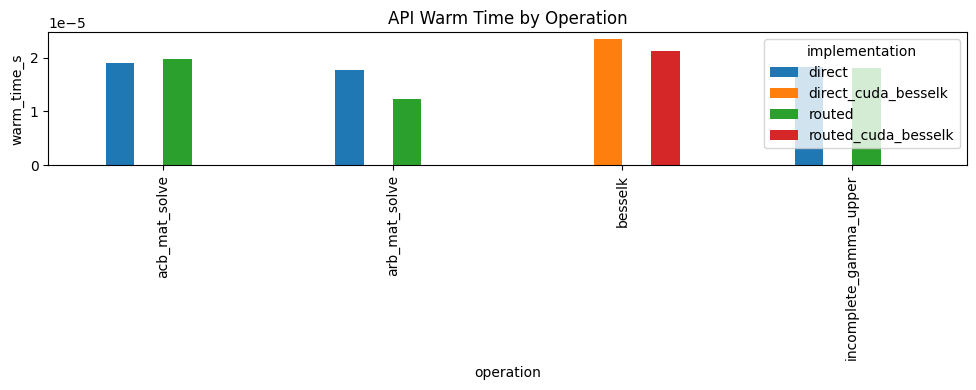

In [10]:
pivot = api_df.pivot(index='operation', columns='implementation', values='warm_time_s')
ax = pivot.plot(kind='bar', figsize=(10, 4), title='API Warm Time by Operation')
ax.set_ylabel('warm_time_s')
plt.tight_layout()
plt.savefig(EXAMPLE_OUTPUT_ROOT / f'api_warm_time_{JAX_MODE}.png', dpi=160, bbox_inches='tight')
plt.show()

## Optional Diagnostics

For compile/memory diagnostics beyond the API benchmark, use `benchmark_matrix_stack_diagnostics.py` or the JAX diagnostics helpers explicitly.

In [11]:
summary_lines = [
    f'# Example API Surface Summary ({JAX_MODE})',
    '',
    f'- python: `{PYTHON}`',
    f'- backend: `{runtime_payload["platform"]}`',
    f'- api_rows: `{len(api_df)}`',
    f'- diagnostics_rows: `{len(diag_df)}`',
    '',
    '## Routed Operations',
    '',
]
for row in summary.reset_index().to_dict(orient='records'):
    summary_lines.append(f"- `{row['operation']}` / `{row['implementation']}`: warm={row['warm_time_s']:.6g}s, cold={row['cold_time_s']:.6g}s, recompile={row['recompile_time_s']:.6g}s")
summary_lines.extend(['', '## Diagnostics Cases', ''])
for row in diag_df.to_dict(orient='records'):
    summary_lines.append(f"- `{row['name']}`: compile_ms={row['compile_ms']:.6g}, steady_ms_median={row['steady_ms_median']:.6g}, recompile_new_shape_ms={row['recompile_new_shape_ms']:.6g}")
(EXAMPLE_OUTPUT_ROOT / f'summary_{JAX_MODE}.md').write_text('\n'.join(summary_lines) + '\n', encoding='utf-8')
display('\n'.join(summary_lines[:16]))

'# Example API Surface Summary (cpu)\n\n- python: `/home/phili/miniforge3/envs/jax/bin/python`\n- backend: `cpu`\n- api_rows: `8`\n- diagnostics_rows: `8`\n\n## Routed Operations\n\n- `acb_mat_solve` / `direct`: warm=1.90687e-05s, cold=0.224302s, recompile=1.7988e-05s\n- `acb_mat_solve` / `routed`: warm=1.98103e-05s, cold=0.174009s, recompile=1.2638e-05s\n- `arb_mat_solve` / `direct`: warm=1.76437e-05s, cold=0.407904s, recompile=1.6739e-05s\n- `arb_mat_solve` / `routed`: warm=1.2266e-05s, cold=0.167525s, recompile=1.124e-05s\n- `besselk` / `direct_cuda_besselk`: warm=2.3523e-05s, cold=0.102939s, recompile=1.0867e-05s\n- `besselk` / `routed_cuda_besselk`: warm=2.12667e-05s, cold=0.538709s, recompile=1.0175e-05s\n- `incomplete_gamma_upper` / `direct`: warm=1.82173e-05s, cold=0.137871s, recompile=1.3549e-05s'